In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

takapuna = pd.read_csv("ASS2data1.csv")
takapuna.head()

,StartofInterval,EndofInterval,"PM2,5.Hourly Aggregate (µg/m³) Average (µg/m³)",PM10.Hourly Aggregate (µg/m³) Average (µg/m³),NO.Hourly Aggregate (µg/m³) Average (mg/m³),NO2.Hourly Aggregate (µg/m³) Average (µg/m³),Air Temp.Hourly Aggregate (°C) Average (°C),Rel Humidity.Hourly Aggregate (%) Average (%),Wind Dir.Hourly Aggregate (°) Average (°),Wind Speed m/s.Hourly Aggregate (m/s) Average (m/s)
0,01-01-2019 00:00,01-01-2019 01:00,10.30,14.80,NaN,NaN,19.0,75.30,230.0,1.15
1,01-01-2019 01:00,01-01-2019 02:00,7.60,14.20,NaN,NaN,19.0,76.05,231.0,1.00
2,01-01-2019 02:00,01-01-2019 03:00,4.90,18.80,0.0030,6.50,19.0,76.70,246.0,1.10
3,01-01-2019 03:00,01-01-2019 04:00,7.25,19.65,0.0025,5.10,19.0,77.35,252.5,1.20
4,01-01-2019 04:00,01-01-2019 05:00,7.55,16.65,0.0021,3.75,19.0,77.20,250.0,1.45


In [2]:
#A)Data preprocessing

print(list(takapuna));
print("Number of observations in the data set:",takapuna.shape[0]);
takapuna.drop_duplicates() 
print("Number of observations in the data set:",takapuna.shape[0]);
print(takapuna.isnull().values.any());
print(takapuna.isnull().sum())
print("Total number of null values:",sum(takapuna.isnull().sum()))


['StartofInterval', 'EndofInterval', 'PM2,5.Hourly Aggregate (µg/m³)  Average (µg/m³)', 'PM10.Hourly Aggregate (µg/m³) Average (µg/m³)', 'NO.Hourly Aggregate (µg/m³) Average (mg/m³)', 'NO2.Hourly Aggregate (µg/m³) Average (µg/m³)', 'Air Temp.Hourly Aggregate (°C) Average (°C)', 'Rel Humidity.Hourly Aggregate (%) Average (%)', 'Wind Dir.Hourly Aggregate (°) Average (°)', 'Wind Speed m/s.Hourly Aggregate (m/s) Average (m/s)']
Number of observations in the data set: 43800
Number of observations in the data set: 43800
True
StartofInterval                                            0
EndofInterval                                              0
PM2,5.Hourly Aggregate (µg/m³)  Average (µg/m³)        16126
PM10.Hourly Aggregate (µg/m³) Average (µg/m³)           1955
NO.Hourly Aggregate (µg/m³) Average (mg/m³)             4430
NO2.Hourly Aggregate (µg/m³) Average (µg/m³)            4430
Air Temp.Hourly Aggregate (°C) Average (°C)             5809
Rel Humidity.Hourly Aggregate (%) Average (%)   

In [3]:
# Convert datetime columns to datetime data type with correct format
takapuna['StartofInterval'] = pd.to_datetime(takapuna['StartofInterval'], format='%d-%m-%Y %H:%M')
takapuna['EndofInterval'] = pd.to_datetime(takapuna['EndofInterval'], format='%d-%m-%Y %H:%M')




print(takapuna.dtypes)

StartofInterval                                        datetime64[ns]
EndofInterval                                          datetime64[ns]
PM2,5.Hourly Aggregate (µg/m³)  Average (µg/m³)               float64
PM10.Hourly Aggregate (µg/m³) Average (µg/m³)                 float64
NO.Hourly Aggregate (µg/m³) Average (mg/m³)                   float64
NO2.Hourly Aggregate (µg/m³) Average (µg/m³)                  float64
Air Temp.Hourly Aggregate (°C) Average (°C)                   float64
Rel Humidity.Hourly Aggregate (%) Average (%)                 float64
Wind Dir.Hourly Aggregate (°) Average (°)                     float64
Wind Speed m/s.Hourly Aggregate (m/s) Average (m/s)           float64
dtype: object


In [4]:
means = takapuna.mean()

# Replace NaN values with the mean of the respective columns
takapuna1 = takapuna.fillna(means)
print(takapuna1.isnull().sum())

StartofInterval                                        0
EndofInterval                                          0
PM2,5.Hourly Aggregate (µg/m³)  Average (µg/m³)        0
PM10.Hourly Aggregate (µg/m³) Average (µg/m³)          0
NO.Hourly Aggregate (µg/m³) Average (mg/m³)            0
NO2.Hourly Aggregate (µg/m³) Average (µg/m³)           0
Air Temp.Hourly Aggregate (°C) Average (°C)            0
Rel Humidity.Hourly Aggregate (%) Average (%)          0
Wind Dir.Hourly Aggregate (°) Average (°)              0
Wind Speed m/s.Hourly Aggregate (m/s) Average (m/s)    0
dtype: int64


In [5]:
cols_to_check_negative = [
    'PM10.Hourly Aggregate (µg/m³) Average (µg/m³)',
    'NO.Hourly Aggregate (µg/m³) Average (mg/m³)',    
    'NO2.Hourly Aggregate (µg/m³) Average (µg/m³)',
    'PM2,5.Hourly Aggregate (µg/m³)  Average (µg/m³)'
]

# Remove rows with negative values in the specified columns
for col in cols_to_check_negative:
    takapuna1 = takapuna1[takapuna1[col] >= 0]
    
stats1 = takapuna1.describe().loc[['min', 'max', 'mean']]
print(stats1)
print("Number of observations in the data:", takapuna1.shape[0])

                    StartofInterval                  EndofInterval  \
min             2019-01-01 00:00:00            2019-01-01 01:00:00   
max             2023-12-30 23:00:00            2023-12-31 00:00:00   
mean  2021-07-05 16:06:37.071701760  2021-07-05 17:06:37.071701760   

      PM2,5.Hourly Aggregate (µg/m³)  Average (µg/m³)  \
min                                          0.200000   
max                                         52.300000   
mean                                         6.738494   

      PM10.Hourly Aggregate (µg/m³) Average (µg/m³)  \
min                                        0.000000   
max                                      437.250000   
mean                                      12.442415   

      NO.Hourly Aggregate (µg/m³) Average (mg/m³)  \
min                                      0.000000   
max                                      0.378950   
mean                                     0.013048   

      NO2.Hourly Aggregate (µg/m³) Average (µg/m³)  \
mi

In [6]:
# Define a function to identify outliers
def detect_outliers(series, lower_bound=None, upper_bound=None):
    outliers = (series < lower_bound) | (series > upper_bound)
    return outliers

# Function to replace outliers with NaN
def replace_outliers_with_nan(df, column, lower_bound, upper_bound):
    outliers = detect_outliers(df[column], lower_bound, upper_bound)
    df.loc[outliers, column] = np.nan
    return df

# Define expected ranges for the attributes
ranges = {
    'Air Temp.Hourly Aggregate (°C) Average (°C)': (5, 30),
    'Rel Humidity.Hourly Aggregate (%) Average (%)': (60, 100),
    'PM2,5.Hourly Aggregate (µg/m³)  Average (µg/m³)': (3, 10),
    'PM10.Hourly Aggregate (µg/m³) Average (µg/m³)': (10, 50),
    'NO.Hourly Aggregate (µg/m³) Average (mg/m³)': (0, 2),
    'NO2.Hourly Aggregate (µg/m³) Average (µg/m³)': (0, 50),
    'Wind Dir.Hourly Aggregate (°) Average (°)': (0, 360),
    'Wind Speed m/s.Hourly Aggregate (m/s) Average (m/s)': (0, 6)    
}



# Detect outliers and count them
outliers_info = {}
for col, (lower, upper) in ranges.items():
    outliers_info[col] = detect_outliers(takapuna1[col], lower, upper).sum()

total_outliers = sum(outliers_info.values())
print("Outliers information per column:", outliers_info)
print("Total number of outliers:", total_outliers)
print("Number of observations in the original data:", takapuna1.shape[0])

# Replace outliers with NaN
takapuna2 = takapuna1.copy()
for col, (lower, upper) in ranges.items():
    takapuna2 = replace_outliers_with_nan(takapuna2, col, lower, upper)

print("Number of observations in the cleaned data (with NaNs):", takapuna2.shape[0])
print(takapuna2.isna().sum())
means = takapuna2.mean()

# Replace NaN values with the mean of the respective columns
takapuna3 = takapuna2.fillna(means)
print(takapuna3.isnull().sum())

print("Number of observations in the data:", takapuna3.shape[0])

Outliers information per column: {'Air Temp.Hourly Aggregate (°C) Average (°C)': 44, 'Rel Humidity.Hourly Aggregate (%) Average (%)': 7413, 'PM2,5.Hourly Aggregate (µg/m³)  Average (µg/m³)': 4698, 'PM10.Hourly Aggregate (µg/m³) Average (µg/m³)': 16370, 'NO.Hourly Aggregate (µg/m³) Average (mg/m³)': 0, 'NO2.Hourly Aggregate (µg/m³) Average (µg/m³)': 422, 'Wind Dir.Hourly Aggregate (°) Average (°)': 0, 'Wind Speed m/s.Hourly Aggregate (m/s) Average (m/s)': 567}
Total number of outliers: 29514
Number of observations in the original data: 43165
Number of observations in the cleaned data (with NaNs): 43165
StartofInterval                                            0
EndofInterval                                              0
PM2,5.Hourly Aggregate (µg/m³)  Average (µg/m³)         4698
PM10.Hourly Aggregate (µg/m³) Average (µg/m³)          16370
NO.Hourly Aggregate (µg/m³) Average (mg/m³)                0
NO2.Hourly Aggregate (µg/m³) Average (µg/m³)             422
Air Temp.Hourly Aggregate

In [7]:
stats3 = takapuna3.describe().loc[['min', 'max', 'mean']]
print(stats3)

                    StartofInterval                  EndofInterval  \
min             2019-01-01 00:00:00            2019-01-01 01:00:00   
max             2023-12-30 23:00:00            2023-12-31 00:00:00   
mean  2021-07-05 16:06:37.071701760  2021-07-05 17:06:37.071701760   

      PM2,5.Hourly Aggregate (µg/m³)  Average (µg/m³)  \
min                                          3.000000   
max                                         10.000000   
mean                                         6.274023   

      PM10.Hourly Aggregate (µg/m³) Average (µg/m³)  \
min                                       10.000000   
max                                       50.000000   
mean                                      15.732509   

      NO.Hourly Aggregate (µg/m³) Average (mg/m³)  \
min                                      0.000000   
max                                      0.378950   
mean                                     0.013048   

      NO2.Hourly Aggregate (µg/m³) Average (µg/m³)  \
mi

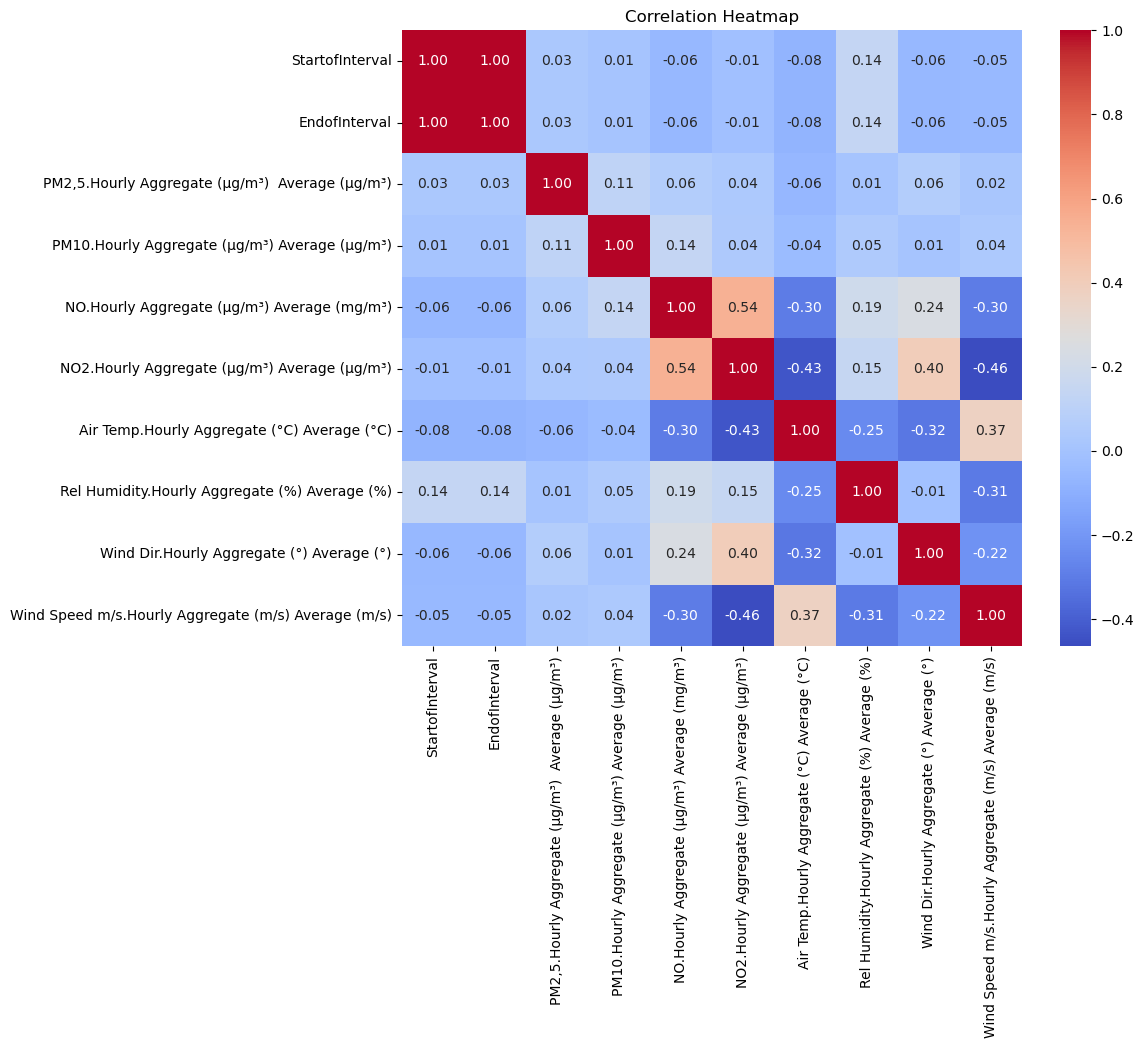

,PM10.Hourly Aggregate (µg/m³) Average (µg/m³)
StartofInterval,0.006825
EndofInterval,0.006825
"PM2,5.Hourly Aggregate (µg/m³) Average (µg/m³)",0.114503
PM10.Hourly Aggregate (µg/m³) Average (µg/m³),1.000000
NO.Hourly Aggregate (µg/m³) Average (mg/m³),0.137069
NO2.Hourly Aggregate (µg/m³) Average (µg/m³),0.041294
Air Temp.Hourly Aggregate (°C) Average (°C),-0.040762
Rel Humidity.Hourly Aggregate (%) Average (%),0.050188
Wind Dir.Hourly Aggregate (°) Average (°),0.005321
Wind Speed m/s.Hourly Aggregate (m/s) Average (m/s),0.036705


In [8]:
import seaborn as sns
corr_matrix = takapuna3.corr(method = 'pearson')
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()
# Extract the correlations with PM2.5 and PM10
pm_correlations = corr_matrix[[ 'PM10.Hourly Aggregate (µg/m³) Average (µg/m³)']]

# Display the correlations
pm_correlations

In [9]:
top_predictors_pm10 = pm_correlations['PM10.Hourly Aggregate (µg/m³) Average (µg/m³)'].abs().sort_values(ascending=False).index[1:7]

print(top_predictors_pm10)

Index(['NO.Hourly Aggregate (µg/m³) Average (mg/m³)',
       'PM2,5.Hourly Aggregate (µg/m³)  Average (µg/m³)',
       'Rel Humidity.Hourly Aggregate (%) Average (%)',
       'NO2.Hourly Aggregate (µg/m³) Average (µg/m³)',
       'Air Temp.Hourly Aggregate (°C) Average (°C)',
       'Wind Speed m/s.Hourly Aggregate (m/s) Average (m/s)'],
      dtype='object')


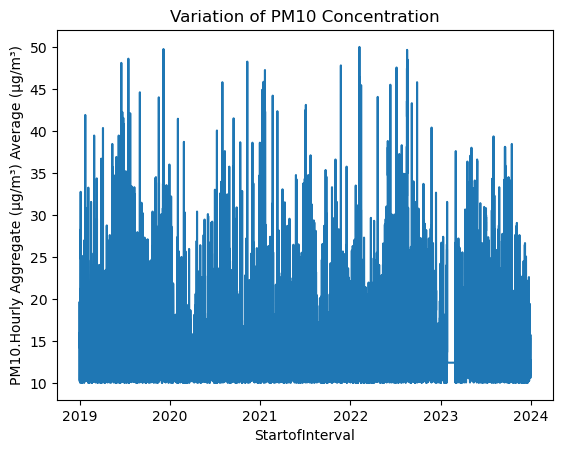

In [10]:
import seaborn as sns
# Plotting the variation of PM concentrations

sns.lineplot(data=takapuna3, x='StartofInterval', y='PM10.Hourly Aggregate (µg/m³) Average (µg/m³)')
plt.title('Variation of PM10 Concentration')

plt.show()

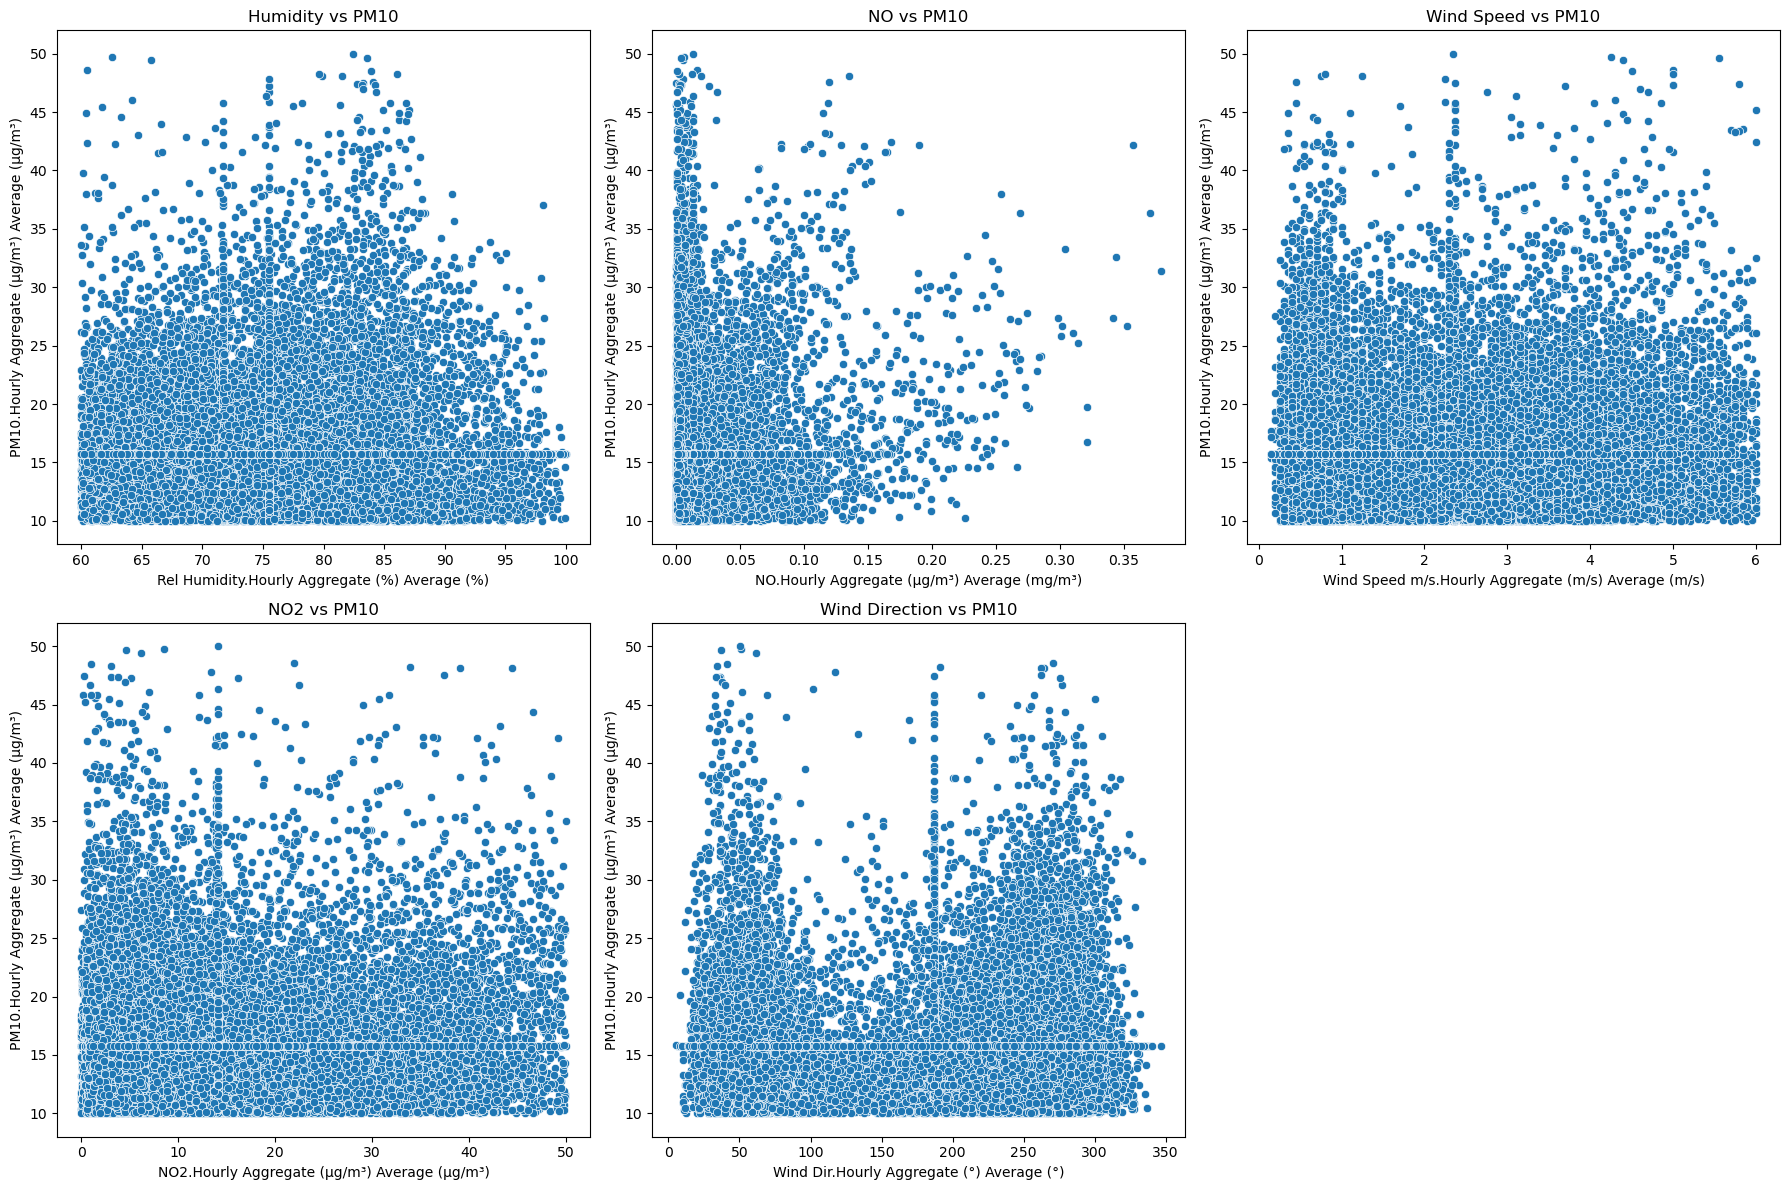

In [11]:
# Plotting the variation of each variable against PM10
plt.figure(figsize=(18, 12))

# Plot 1: PM2.5 against PM10
plt.subplot(2, 3, 1)
sns.scatterplot(data=takapuna3, x='Rel Humidity.Hourly Aggregate (%) Average (%)', y='PM10.Hourly Aggregate (µg/m³) Average (µg/m³)')
plt.title('Humidity vs PM10')

# Plot 2: NO against PM10
plt.subplot(2, 3, 2)
sns.scatterplot(data=takapuna3, x='NO.Hourly Aggregate (µg/m³) Average (mg/m³)', y='PM10.Hourly Aggregate (µg/m³) Average (µg/m³)')
plt.title('NO vs PM10')

# Plot 3: Wind Speed against PM10
plt.subplot(2, 3, 3)
sns.scatterplot(data=takapuna3, x='Wind Speed m/s.Hourly Aggregate (m/s) Average (m/s)', y='PM10.Hourly Aggregate (µg/m³) Average (µg/m³)')
plt.title('Wind Speed vs PM10')

# Plot 4: NO2 against PM10
plt.subplot(2, 3, 4)
sns.scatterplot(data=takapuna3, x='NO2.Hourly Aggregate (µg/m³) Average (µg/m³)', y='PM10.Hourly Aggregate (µg/m³) Average (µg/m³)')
plt.title('NO2 vs PM10')

# Plot 5: Wind Direction against PM10
plt.subplot(2, 3, 5)
sns.scatterplot(data=takapuna3, x='Wind Dir.Hourly Aggregate (°) Average (°)', y='PM10.Hourly Aggregate (µg/m³) Average (µg/m³)')
plt.title('Wind Direction vs PM10')

plt.tight_layout()
plt.show()

In [12]:
#Creating new dataset with just the predictors
columns = ['StartofInterval','EndofInterval','NO.Hourly Aggregate (µg/m³) Average (mg/m³)',
           'Air Temp.Hourly Aggregate (°C) Average (°C)', 'NO2.Hourly Aggregate (µg/m³) Average (µg/m³)',
           'Wind Speed m/s.Hourly Aggregate (m/s) Average (m/s)','Rel Humidity.Hourly Aggregate (%) Average (%)', 'PM10.Hourly Aggregate (µg/m³) Average (µg/m³)']

# Create a new DataFrame with only the specified columns
takapunaf = takapuna3[columns].copy()
takapunaf.head()

,StartofInterval,EndofInterval,NO.Hourly Aggregate (µg/m³) Average (mg/m³),Air Temp.Hourly Aggregate (°C) Average (°C),NO2.Hourly Aggregate (µg/m³) Average (µg/m³),Wind Speed m/s.Hourly Aggregate (m/s) Average (m/s),Rel Humidity.Hourly Aggregate (%) Average (%),PM10.Hourly Aggregate (µg/m³) Average (µg/m³)
0,2019-01-01 00:00:00,2019-01-01 01:00:00,0.012878,19.0,14.134854,1.15,75.30,14.80
1,2019-01-01 01:00:00,2019-01-01 02:00:00,0.012878,19.0,14.134854,1.00,76.05,14.20
2,2019-01-01 02:00:00,2019-01-01 03:00:00,0.003000,19.0,6.500000,1.10,76.70,18.80
3,2019-01-01 03:00:00,2019-01-01 04:00:00,0.002500,19.0,5.100000,1.20,77.35,19.65
4,2019-01-01 04:00:00,2019-01-01 05:00:00,0.002100,19.0,3.750000,1.45,77.20,16.65


In [13]:
import pandas as pd

# Fixing the column names
pm10_column_name = takapunaf.columns[takapunaf.columns.str.contains('PM10')][0]

# Creating lag1 and lag2 for PM10
takapunaf['PM10_lag1'] = takapunaf[pm10_column_name].shift(1)
takapunaf['PM10_lag2'] = takapunaf[pm10_column_name].shift(2)

# Save the updated dataframe to a new CSV file
output_file_path = 'C:/Users/RAHUL - AUT/OneDrive - AUT University/Semester 1/Machine Leaning and Data Mining/Assignment/A2/Data Final/takapunaf.csv'
takapunaf.to_csv(output_file_path, index=False)

print("Updated data with PM10 Lags has been exported to 'takapunaf.csv'")

OSError: Cannot save file into a non-existent directory: 'C:\Users\RAHUL - AUT\OneDrive - AUT University\Semester 1\Machine Leaning and Data Mining\Assignment\A2\Data Final'

In [14]:
#Creating new dataset with just the predictors
columns = ['StartofInterval','EndofInterval','NO.Hourly Aggregate (µg/m³) Average (mg/m³)',
           'Air Temp.Hourly Aggregate (°C) Average (°C)', 'NO2.Hourly Aggregate (µg/m³) Average (µg/m³)',
           'Wind Speed m/s.Hourly Aggregate (m/s) Average (m/s)','Rel Humidity.Hourly Aggregate (%) Average (%)','PM10_lag1','PM10_lag2', 'PM10.Hourly Aggregate (µg/m³) Average (µg/m³)']

# Create a new DataFrame with only the specified columns
MLPtakapuna = takapunaf[columns].copy()
MLPtakapuna.head()

,StartofInterval,EndofInterval,NO.Hourly Aggregate (µg/m³) Average (mg/m³),Air Temp.Hourly Aggregate (°C) Average (°C),NO2.Hourly Aggregate (µg/m³) Average (µg/m³),Wind Speed m/s.Hourly Aggregate (m/s) Average (m/s),Rel Humidity.Hourly Aggregate (%) Average (%),PM10_lag1,PM10_lag2,PM10.Hourly Aggregate (µg/m³) Average (µg/m³)
0,2019-01-01 00:00:00,2019-01-01 01:00:00,0.012878,19.0,14.134854,1.15,75.30,NaN,NaN,14.80
1,2019-01-01 01:00:00,2019-01-01 02:00:00,0.012878,19.0,14.134854,1.00,76.05,14.80,NaN,14.20
2,2019-01-01 02:00:00,2019-01-01 03:00:00,0.003000,19.0,6.500000,1.10,76.70,14.20,14.8,18.80
3,2019-01-01 03:00:00,2019-01-01 04:00:00,0.002500,19.0,5.100000,1.20,77.35,18.80,14.2,19.65
4,2019-01-01 04:00:00,2019-01-01 05:00:00,0.002100,19.0,3.750000,1.45,77.20,19.65,18.8,16.65


In [ ]:
#MLP
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, roc_auc_score, classification_report


import itertools

import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Check the dimension of your dataset
print("Takapuna data set dimensions : {}".format(MLPtakapuna.shape))

# Our dataset has 43165 observations/instances/rows and 10 attributes/columns

In [ ]:
# Task 3: Set the input (X) and output/target (y) 

X = MLPtakapuna.iloc[:, 2:-1].values 
y = MLPtakapuna.iloc[:, -1].values

#counting values of variables in 'Outcome'
print(MLPtakapuna.columns)
print(MLPtakapuna.head())

In [ ]:
# Scale the predictor variables
sc = StandardScaler()
X_scaled = sc.fit_transform(X)

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Exclude non-numeric columns
numeric_df = MLPtakapuna.select_dtypes(include=[float, int])

# Generate the heatmap
plt.figure(figsize=(12, 10))  # Set the size of the figure to 12 by 10.
sns.heatmap(numeric_df.corr(), annot=True, cmap='PiYG')
plt.show()

In [ ]:
#Task 5 Show summary statistics
print(MLPtakapuna.describe())

In [ ]:
#Task 6: Splitting Data
from sklearn.model_selection import train_test_split

# Define the target column
target_column = 'PM10.Hourly Aggregate (µg/m³) Average (µg/m³)'

# Features are all columns except the target column
features = MLPtakapuna.drop(columns=[target_column])

# Target is the target column
target = MLPtakapuna[target_column]

# Split the data into training (70%) and testing (30%) sets
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.3, random_state=42, shuffle=False)

# Verify the shapes of the resulting datasets
print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")
print(f"Training target shape: {y_train.shape}")
print(f"Testing target shape: {y_test.shape}")

In [ ]:
#Task 7 Single Layer Baseline MLP

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

# Load the dataset
dataset_path = 'takapunaf.csv'
MLPtakapuna = pd.read_csv(dataset_path)

# Convert datetime strings to datetime objects
MLPtakapuna['StartofInterval'] = pd.to_datetime(MLPtakapuna['StartofInterval'])

# Extract numerical features from datetime objects
MLPtakapuna['year'] = MLPtakapuna['StartofInterval'].dt.year
MLPtakapuna['month'] = MLPtakapuna['StartofInterval'].dt.month
MLPtakapuna['day'] = MLPtakapuna['StartofInterval'].dt.day
MLPtakapuna['hour'] = MLPtakapuna['StartofInterval'].dt.hour

# Drop the original datetime columns
MLPtakapuna.drop(['StartofInterval', 'EndofInterval'], axis=1, inplace=True)

# Handle missing values by filling with the mean of each column
MLPtakapuna.fillna(MLPtakapuna.mean(), inplace=True)

# Define the target column
target_column = 'PM10.Hourly Aggregate (µg/m³) Average (µg/m³)'

# Features are all columns except the target column
features = MLPtakapuna.drop(columns=[target_column])

# Target is the target column
target = MLPtakapuna[target_column]

# Split the data into training (70%) and testing (30%) sets
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.3, random_state=42)

# List of learning rates to experiment with
learning_rates = [0.001, 0.01, 0.1, 0.2, 0.5]

# Initialize variables to store the best learning rate and corresponding performance metrics
best_learning_rate = None
best_mse = float('inf')
best_mae = float('inf')
best_r2 = float('-inf')
best_model = None

# Experiment with different learning rates
for lr in learning_rates:
    # Define the MLP model with a single hidden layer of 25 neurons and the current learning rate
    mlp = MLPRegressor(hidden_layer_sizes=(25,), learning_rate_init=lr, max_iter=1000, random_state=42)

    # Fit the model
    mlp.fit(X_train, y_train)

    # Predictions
    y_pred_mlp = mlp.predict(X_test)
    mse_mlp = mean_squared_error(y_test, y_pred_mlp)
    mae_mlp = mean_absolute_error(y_test, y_pred_mlp)
    r2_mlp = r2_score(y_test, y_pred_mlp)

    # Print performance metrics for the current learning rate
    print(f"Learning rate: {lr}")
    print(f"MSE: {mse_mlp}")
    print(f"MAE: {mae_mlp}")
    print(f"R2: {r2_mlp}")
    print(f"Number of iterations: {mlp.n_iter_}\n")

    # Update the best learning rate if the current model performs better
    if mse_mlp < best_mse:
        best_learning_rate = lr
        best_mse = mse_mlp
        best_mae = mae_mlp
        best_r2 = r2_mlp
        best_model = mlp

# Print the best learning rate and corresponding performance metrics
print(f"Best learning rate: {best_learning_rate}")
print(f"Best MSE: {best_mse}")
print(f"Best MAE: {best_mae}")
print(f"Best R2: {best_r2}")

# Plotting loss curve for the best single-layer model
plt.figure(figsize=(10, 5))
plt.plot(best_model.loss_curve_)
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.title(f'Loss Curve for Single-Layer MLP (25 neurons) with Best LR: {best_learning_rate}')
plt.show()


In [ ]:
# Task 8 Two-hidden-layer MLP

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

# Load the dataset
dataset_path = 'takapunaf.csv'
MLPtakapuna = pd.read_csv(dataset_path)

# Convert datetime strings to datetime objects
MLPtakapuna['StartofInterval'] = pd.to_datetime(MLPtakapuna['StartofInterval'])

# Extract numerical features from datetime objects
MLPtakapuna['year'] = MLPtakapuna['StartofInterval'].dt.year
MLPtakapuna['month'] = MLPtakapuna['StartofInterval'].dt.month
MLPtakapuna['day'] = MLPtakapuna['StartofInterval'].dt.day
MLPtakapuna['hour'] = MLPtakapuna['StartofInterval'].dt.hour

# Drop the original datetime columns
MLPtakapuna.drop(['StartofInterval', 'EndofInterval'], axis=1, inplace=True)

# Handle missing values by filling with the mean of each column
MLPtakapuna.fillna(MLPtakapuna.mean(), inplace=True)

# Define the target column
target_column = 'PM10.Hourly Aggregate (µg/m³) Average (µg/m³)'

# Features are all columns except the target column
features = MLPtakapuna.drop(columns=[target_column])

# Target is the target column
target = MLPtakapuna[target_column]

# Split the data into training (70%) and testing (30%) sets
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.3, random_state=42)

# Initialize variables to store the best configuration and corresponding performance metrics
best_configuration = None
best_mse = float('inf')
best_mae = float('inf')
best_r2 = float('-inf')
best_model = None

# Total neurons to be distributed across two layers
k = 25

# Experiment with different splits of neurons between the two hidden layers
for i in range(1, k):
    neurons_layer1 = k - i
    neurons_layer2 = i

    # Define the MLP model with the current configuration of neurons across two layers
    mlp = MLPRegressor(hidden_layer_sizes=(neurons_layer1, neurons_layer2), max_iter=1000, random_state=42)

    # Fit the model
    mlp.fit(X_train, y_train)

    # Predictions
    y_pred_mlp = mlp.predict(X_test)
    mse_mlp = mean_squared_error(y_test, y_pred_mlp)
    mae_mlp = mean_absolute_error(y_test, y_pred_mlp)
    r2_mlp = r2_score(y_test, y_pred_mlp)

    # Print performance metrics for the current configuration
    print(f"Configuration: ({neurons_layer1}, {neurons_layer2})")
    print(f"MSE: {mse_mlp}")
    print(f"MAE: {mae_mlp}")
    print(f"R2: {r2_mlp}")
    print(f"Number of iterations: {mlp.n_iter_}\n")

    # Update the best configuration if the current model performs better
    if mse_mlp < best_mse:
        best_configuration = (neurons_layer1, neurons_layer2)
        best_mse = mse_mlp
        best_mae = mae_mlp
        best_r2 = r2_mlp
        best_model = mlp

# Print the best configuration and corresponding performance metrics
print(f"Best configuration: {best_configuration}")
print(f"Best MSE: {best_mse}")
print(f"Best MAE: {best_mae}")
print(f"Best R2: {best_r2}")

# Plotting loss curve for the best two-layer model
plt.figure(figsize=(10, 5))
plt.plot(best_model.loss_curve_)
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.title(f'Loss Curve for Two-Layer MLP {best_configuration}')
plt.show()

# Calculate and print the correlation coefficient
correlation_coefficient = np.corrcoef(y_test, best_model.predict(X_test))[0, 1]
print(f"Correlation Coefficient: {correlation_coefficient}")


In [ ]:
# Question 4

# Best single-layer model from previous experiment
best_learning_rate = 0.01  # we identified 0.01 as the best learning rate
mlp_single_layer = MLPRegressor(hidden_layer_sizes=(25,), learning_rate_init=best_learning_rate, max_iter=1000, random_state=42)
mlp_single_layer.fit(X_train, y_train)

# Predictions
y_pred_single_layer = mlp_single_layer.predict(X_test)

# Plotting actual vs predicted for single-layer model
plt.figure(figsize=(10, 5))
plt.plot(y_test.values, label='Actual PM10')
plt.plot(y_pred_single_layer, label='Predicted PM10 (Single Layer)')
plt.xlabel('Samples')
plt.ylabel('PM10')
plt.title('Actual vs Predicted PM10 (Single Layer)')
plt.legend()
plt.show()

# Calculate RMSE
rmse_single_layer = np.sqrt(mean_squared_error(y_test, y_pred_single_layer))
print(f"RMSE for Single-Layer MLP: {rmse_single_layer}")

# Calculate MAE
mae_single_layer = mean_absolute_error(y_test, y_pred_single_layer)
print(f"MAE for Single-Layer MLP: {mae_single_layer}")

# Calculate R² (correlation coefficient)
r2_single_layer = r2_score(y_test, y_pred_single_layer)
print(f"R² for Single-Layer MLP: {r2_single_layer}")

In [ ]:
# Two-Layer Configuration (11, 14 neurons)
mlp_two_layer = MLPRegressor(hidden_layer_sizes=(23, 2), max_iter=1000, random_state=42)
mlp_two_layer.fit(X_train, y_train)

# Predictions
y_pred_two_layer = mlp_two_layer.predict(X_test)

# Plotting actual vs predicted for two-layer model
plt.figure(figsize=(10, 5))
plt.plot(y_test.values, label='Actual PM10')
plt.plot(y_pred_two_layer, label='Predicted PM10 (Two Layers)')
plt.xlabel('Samples')
plt.ylabel('PM10')
plt.title('Actual vs Predicted PM10 (Two Layers)')
plt.legend()
plt.show()

# Calculate RMSE
rmse_two_layer = np.sqrt(mean_squared_error(y_test, y_pred_two_layer))
print(f"RMSE for Two-Layer MLP: {rmse_two_layer}")

# Calculate MAE
mae_two_layer = mean_absolute_error(y_test, y_pred_two_layer)
print(f"MAE for Two-Layer MLP: {mae_two_layer}")

# Calculate R² (correlation coefficient)
r2_two_layer = r2_score(y_test, y_pred_two_layer)
print(f"R² for Two-Layer MLP: {r2_two_layer}")

In [15]:
#LSTM

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import *
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.metrics import MeanAbsoluteError, RootMeanSquaredError
from sklearn.metrics import r2_score 
from sklearn.metrics import mean_squared_error 
from sklearn.metrics import mean_absolute_error 
import time
import math
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

In [16]:
#Creating new dataset with just the predictors
columns = ['EndofInterval','PM10.Hourly Aggregate (µg/m³) Average (µg/m³)','NO.Hourly Aggregate (µg/m³) Average (mg/m³)',
           'Air Temp.Hourly Aggregate (°C) Average (°C)', 'NO2.Hourly Aggregate (µg/m³) Average (µg/m³)',
           'Wind Speed m/s.Hourly Aggregate (m/s) Average (m/s)','Rel Humidity.Hourly Aggregate (%) Average (%)']

# Create a new DataFrame with only the specified columns
takapunaf = takapuna3[columns].copy()
takapunaf.head()

,EndofInterval,PM10.Hourly Aggregate (µg/m³) Average (µg/m³),NO.Hourly Aggregate (µg/m³) Average (mg/m³),Air Temp.Hourly Aggregate (°C) Average (°C),NO2.Hourly Aggregate (µg/m³) Average (µg/m³),Wind Speed m/s.Hourly Aggregate (m/s) Average (m/s),Rel Humidity.Hourly Aggregate (%) Average (%)
0,2019-01-01 01:00:00,14.80,0.012878,19.0,14.134854,1.15,75.30
1,2019-01-01 02:00:00,14.20,0.012878,19.0,14.134854,1.00,76.05
2,2019-01-01 03:00:00,18.80,0.003000,19.0,6.500000,1.10,76.70
3,2019-01-01 04:00:00,19.65,0.002500,19.0,5.100000,1.20,77.35
4,2019-01-01 05:00:00,16.65,0.002100,19.0,3.750000,1.45,77.20


In [17]:
takapunaf.drop('EndofInterval', axis=1, inplace=True)

# creating train and test sets
dataset = takapunaf.values



n = len(dataset)
train = dataset[0:int(n * 0.7)]  # 0 ~~ 70%
valid = dataset[int(n * 0.7):]  # 70% ~~ end

scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(dataset)

print(scaled_data)

[[0.12       0.03398284 0.60869565 0.28269708 0.17094017 0.3825    ]
 [0.105      0.03398284 0.60869565 0.28269708 0.14529915 0.40125   ]
 [0.22       0.00791661 0.60869565 0.13       0.16239316 0.4175    ]
 ...
 [0.01625    0.00580552 0.76086957 0.29       0.07692308 0.455     ]
 [0.14331273 0.00356248 0.73913043 0.219      0.11111111 0.545     ]
 [0.0675     0.00105555 0.7173913  0.122      0.11965812 0.71125   ]]


In [19]:
# Define Cost Function
def mean_squared_error(y_true, y_pred):
    return np.mean(np.square(y_true - y_pred))

# Scale the data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_train = scaler.fit_transform(train)
scaled_valid = scaler.transform(valid)

# Define time steps
time_step = 100

# Prepare training data
x_train, y_train = [], []
for i in range(time_step, len(scaled_train)):
    x_train.append(scaled_train[i - time_step:i, 0])
    y_train.append(scaled_train[i, 0])
x_train, y_train = np.array(x_train), np.array(y_train)
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))

# Prepare validation data
x_valid, y_valid = [], []
for i in range(time_step, len(scaled_valid)):
    x_valid.append(scaled_valid[i - time_step:i, 0])
    y_valid.append(scaled_valid[i, 0])
x_valid, y_valid = np.array(x_valid), np.array(y_valid)
x_valid = np.reshape(x_valid, (x_valid.shape[0], x_valid.shape[1], 1))

In [20]:
#CHECKING BEST EPOCH
# Build the LSTM model
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(x_train.shape[1], 1)))
model.add(Dropout(0.2))
model.add(LSTM(units=50, return_sequences=True))
model.add(Dropout(0.2))
model.add(LSTM(units=50, return_sequences=True))
model.add(Dropout(0.2))
model.add(LSTM(units=50))
model.add(Dropout(0.2))
model.add(Dense(1))

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.01), loss='mean_squared_error')

In [21]:
# Initialize lists to store losses and run times
train_losses = []
val_losses = []
run_times = []

runs = 30
batch_size = 4
epochs = 10

for run in range(runs):
    start_time = time.time()
    
    # Fit the model
    history = model.fit(x_train, y_train, epochs=epochs, batch_size=batch_size, validation_data=(x_valid, y_valid), verbose=1)
    
    end_time = time.time()

    # Append losses for each epoch
    train_losses.append(history.history['loss'])
    val_losses.append(history.history['val_loss'])
    run_times.append(end_time - start_time)

    # Print progress
    print(f"Run {run + 1} completed in {end_time - start_time} sec")

Epoch 1/10
 353/7529 ━━━━━━━━━━━━━━━━━━━━ 5:07 43ms/step - loss: 0.0141

KeyboardInterrupt: 

In [ ]:
# Plot training and validation losses
plt.figure(figsize=(10, 5))
for i in range(runs):
    plt.plot(range(1, epochs + 1), train_losses[i], label=f'Training Run {i+1}')
    plt.plot(range(1, epochs + 1), val_losses[i], label=f'Validation Run {i+1}')

plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
#plt.legend()
plt.grid(True)
plt.show()



# Plot training losses
plt.figure(figsize=(10, 5))
for i in range(runs):
    plt.plot(range(1, epochs + 1), train_losses[i], label=f"Run {i + 1}")

plt.title('Training Losses')
plt.xlabel('Epoch')
plt.ylabel('Loss')
#plt.legend()
plt.show()

# Plot validation losses
plt.figure(figsize=(10, 5))
for i in range(runs):
    plt.plot(range(1, epochs + 1), val_losses[i], label=f"Run {i + 1}")

plt.title('Validation Losses')
plt.xlabel('Epoch')
plt.ylabel('Loss')
#plt.legend()
plt.show()

In [ ]:
train_loss_stats = {
    'Mean': np.mean(train_losses, axis=0),
    'Std Dev': np.std(train_losses, axis=0),
    'Min': np.min(train_losses, axis=0),
    'Max': np.max(train_losses, axis=0)
}

val_loss_stats = {
    'Mean': np.mean(val_losses, axis=0),
    'Std Dev': np.std(val_losses, axis=0),
    'Min': np.min(val_losses, axis=0),
    'Max': np.max(val_losses, axis=0)
}

run_time_stats = {
    'Mean': np.mean(run_times),
    'Std Dev': np.std(run_times),
    'Min': np.min(run_times),
    'Max': np.max(run_times)
}

# Print summary statistics
print("\nTrain Loss Summary Statistics:")
for stat, value in train_loss_stats.items():
    print(f"{stat}: {value}")

print("\nValidation Loss Summary Statistics:")
for stat, value in val_loss_stats.items():
    print(f"{stat}: {value}")

print("\nRun Time Summary Statistics:")
for stat, value in run_time_stats.items():
    print(f"{stat}: {value}")

# Choose the best epoch based on mean validation loss across runs
mean_val_losses = val_loss_stats['Mean']
best_epoch = np.argmin(mean_val_losses) + 1
print(f"\nBest Epoch: {best_epoch}")
print(f"Mean Validation Loss at Best Epoch: {mean_val_losses[best_epoch - 1]}")

In [ ]:
#CHECKING BEST BATCH SIZE
# List of batch sizes to experiment with
batch_sizes = [64, 32, 16, 8, 4]

# Best number of epochs from the previous step
best_epochs = 5  

# Dictionary to store the summary statistics for each batch size
summary_stats = {}

# Iterate over each batch size
for batch_size in batch_sizes:
    print(f"Evaluating batch size: {batch_size}")
    
    # Initialize lists to store losses and run times for the current batch size
    train_losses = []
    val_losses = []
    run_times = []

    # Number of runs for each batch size
    runs = 30

    # Run training loop for the specified number of runs
    for run in range(runs):

        # Start time measurement
        start_time = time.time()
        
        # Fit the model
        history = model.fit(x_train, y_train, epochs=best_epochs, batch_size=batch_size, validation_data=(x_valid, y_valid), verbose=1)
        
        # End time measurement
        end_time = time.time()

        # Store epoch losses
        train_losses.append(history.history['loss'])
        val_losses.append(history.history['val_loss'])

        # Append run time
        run_times.append(end_time - start_time)

        # Print progress
        print(f"Run {run + 1}/{runs} completed in {end_time - start_time} sec")

    # Store the losses and run times for the current batch size
    summary_stats[batch_size] = {
        'Train Loss': train_losses,
        'Validation Loss': val_losses,
        'Run Time': run_times
    }
    # Calculate summary statistics for the current batch size
    train_loss_stats = {
        'Mean': np.mean(train_losses),
        'Std Dev': np.std(train_losses),
        'Min': np.min(train_losses),
        'Max': np.max(train_losses)
    }

    val_loss_stats = {
        'Mean': np.mean(val_losses),
        'Std Dev': np.std(val_losses),
        'Min': np.min(val_losses),
        'Max': np.max(val_losses)
    }

    run_time_stats = {
        'Mean': np.mean(run_times),
        'Std Dev': np.std(run_times),
        'Min': np.min(run_times),
        'Max': np.max(run_times)
    }

    # Store the summary statistics for the current batch size
    summary_stats[batch_size] = {
        'Train Loss': train_loss_stats,
        'Validation Loss': val_loss_stats,
        'Run Time': run_time_stats
    }

    # Print summary statistics for the current batch size
    print(f"\nSummary for batch size {batch_size}:")
    print("Train Loss Summary Statistics:")
    for stat, value in train_loss_stats.items():
        print(f"{stat}: {value}")

    print("Validation Loss Summary Statistics:")
    for stat, value in val_loss_stats.items():
        print(f"{stat}: {value}")

    print("Run Time Summary Statistics:")
    for stat, value in run_time_stats.items():
        print(f"{stat}: {value}")

In [ ]:
# Plot the mean validation losses for each batch size
mean_val_losses = [summary_stats[bs]['Validation Loss']['Mean'] for bs in batch_sizes]
plt.figure(figsize=(12, 6))
plt.plot(batch_sizes, mean_val_losses, marker='o')
plt.xlabel('Batch Size')
plt.ylabel('Mean Validation Loss')
plt.title('Mean Validation Loss for Different Batch Sizes')
plt.show()

# Find the best batch size based on the lowest mean validation loss
best_batch_size = batch_sizes[np.argmin(mean_val_losses)]
print(f"\nBest Batch Size: {best_batch_size}")
print(f"Validation Loss at Best Batch Size: {min(mean_val_losses)}")

In [ ]:
#CHECKING FOR OPTIMAL NEURONS
neurons = [25, 50, 100, 120]

# Best number of epochs from the previous step
best_epochs = 5

# Best batch size from the previous step
best_batch_size = 32

# Dictionary to store the summary statistics for each number of neurons
summary_stats_neurons = {}

# Iterate over each number of neurons
for neuron in neurons:
    print(f"Evaluating number of neurons: {neuron}")
    
    # Initialize lists to store losses and run times for the current number of neurons
    train_losses_all = []
    val_losses_all = []
    run_times_all = []

    # Number of runs for each number of neurons
    runs = 30

    # Build the LSTM model with the current number of neurons
    model_neurons = Sequential()
    model_neurons.add(LSTM(units=neuron, return_sequences=True, input_shape=(x_train.shape[1], 1)))
    model_neurons.add(Dropout(0.2))
    model_neurons.add(LSTM(units=neuron, return_sequences=True))
    model_neurons.add(Dropout(0.2))
    model_neurons.add(LSTM(units=neuron, return_sequences=True))
    model_neurons.add(Dropout(0.2))
    model_neurons.add(LSTM(units=neuron))
    model_neurons.add(Dropout(0.2))
    model_neurons.add(Dense(1))

    # Compile the model
    model_neurons.compile(optimizer=Adam(learning_rate=0.01), loss='mean_squared_error')

    # Run training loop for the specified number of runs
    for run in range(runs):
        # Initialize lists to store losses for each epoch in the current run
        epoch_train_losses = []
        epoch_val_losses = []

        # Start time measurement
        start_time = time.time()
        
        # Fit the model
        history = model_neurons.fit(x_train, y_train, epochs=best_epochs, batch_size=best_batch_size, validation_data=(x_valid, y_valid), verbose=1)
        
        # End time measurement
        end_time = time.time()

        # Store epoch losses for the current run
        epoch_train_losses.extend(history.history['loss'])
        epoch_val_losses.extend(history.history['val_loss'])

        # Append run time for the current run
        run_times_all.append(end_time - start_time)

        # Append epoch losses for the current run
        train_losses_all.append(epoch_train_losses)
        val_losses_all.append(epoch_val_losses)

        # Print progress
        print(f"Run {run + 1}/{runs} completed in {end_time - start_time} sec")

    # Store the losses and run times for the current number of neurons
    summary_stats_neurons[neuron] = {
        'Train Loss': train_losses_all,
        'Validation Loss': val_losses_all,
        'Run Time': run_times_all
    }

# Calculate summary statistics and export as CSV
summary_stats_list = []

for neuron, stats in summary_stats_neurons.items():
    mean_train_loss = np.mean([np.mean(run) for run in stats['Train Loss']])
    std_train_loss = np.std([np.mean(run) for run in stats['Train Loss']])
    min_train_loss = np.min([np.min(run) for run in stats['Train Loss']])
    max_train_loss = np.max([np.max(run) for run in stats['Train Loss']])
    
    mean_val_loss = np.mean([np.mean(run) for run in stats['Validation Loss']])
    std_val_loss = np.std([np.mean(run) for run in stats['Validation Loss']])
    min_val_loss = np.min([np.min(run) for run in stats['Validation Loss']])
    max_val_loss = np.max([np.max(run) for run in stats['Validation Loss']])
    
    mean_run_time = np.mean(stats['Run Time'])
    std_run_time = np.std(stats['Run Time'])
    min_run_time = np.min(stats['Run Time'])
    max_run_time = np.max(stats['Run Time'])
    
    summary_stats_list.append({
        'Neurons': neuron,
        'Mean Train Loss': mean_train_loss,
        'Std Dev Train Loss': std_train_loss,
        'Min Train Loss': min_train_loss,
        'Max Train Loss': max_train_loss,
        'Mean Validation Loss': mean_val_loss,
        'Std Dev Validation Loss': std_val_loss,
        'Min Validation Loss': min_val_loss,
        'Max Validation Loss': max_val_loss,
        'Mean Run Time': mean_run_time,
        'Std Dev Run Time': std_run_time,
        'Min Run Time': min_run_time,
        'Max Run Time': max_run_time,
    })

summary_stats_df = pd.DataFrame(summary_stats_list)

In [ ]:
# Plot the mean validation losses for each number of neurons
mean_val_losses_neurons = [stats['Mean Validation Loss'] for stats in summary_stats_list]
plt.figure(figsize=(12, 6))
plt.plot(neurons, mean_val_losses_neurons, marker='o')
plt.xlabel('Number of Neurons')
plt.ylabel('Mean Validation Loss')
plt.title('Mean Validation Loss for Different Number of Neurons in Hidden Layer')


plt.show()


# Find the optimal number of neurons based on the lowest mean validation loss
optimal_neurons = neurons[np.argmin(mean_val_losses_neurons)]
print(f"\nOptimal Number of Neurons: {optimal_neurons}")
print(f"Validation Loss at Optimal Number of Neurons: {min(mean_val_losses_neurons)}")

In [ ]:
#OPTIMAL PREDICTIVE MODEL

# Build the LSTM with 120 neurons and 4  layers.
model = Sequential()
model.add(LSTM(units=120, return_sequences=True, input_shape=(x_train.shape[1], 1)))
model.add(Dropout(0.2))
# Adding a second LSTM layer and some Dropout regularisation
model.add(LSTM(units = 120, return_sequences = True))
model.add(Dropout(0.2))
# Adding a third LSTM layer and some Dropout regularisation
model.add(LSTM(units = 120, return_sequences = True))
model.add(Dropout(0.2))
# Adding a fourth LSTM layer and some Dropout regularisation
model.add(LSTM(units = 120))
model.add(Dropout(0.2))
model.add(Dense(1))

# Compile
model.compile(optimizer = 'adam', loss = 'mean_squared_error')

# Fitting the model to the Training set
model.fit(x_train, y_train, epochs = 5, batch_size = 32)

In [ ]:
pm10 = model.predict(x_valid)

# Inverse scale the predictions
# Since we only need to inverse transform the PM10 predictions
pm10 = pm10.reshape(-1, 1)
pm10_inverse = scaler.inverse_transform(np.concatenate((pm10, np.zeros((pm10.shape[0], scaled_data.shape[1] - 1))), axis=1))[:, 0]

# Calculate mean absolute error
mae = np.mean(np.abs(valid[time_step:, 0] - pm10_inverse))
print('Mean Absolute Error:', mae)

# Calculate RMSE
rms = np.sqrt(np.mean(np.power((valid[time_step:, 0] - pm10_inverse), 2)))
print('RMSE:', rms)

# Calculate R-Squared
correlation_matrix = np.corrcoef(valid[time_step:, 0].flatten(), pm10_inverse.flatten())
correlation_xy = correlation_matrix[0, 1]
r_squared = correlation_xy ** 2
print('R-Squared:', r_squared)


In [ ]:
# Plotting
valid_df = pd.DataFrame(valid, columns=takapunaf.columns)
valid_df['Predictions'] = np.nan
valid_df.iloc[time_step:, valid_df.columns.get_loc('Predictions')] = pm10_inverse


plt.figure(figsize=(16, 8))
plt.plot(valid_df['PM10.Hourly Aggregate (µg/m³) Average (µg/m³)'], label='Validation Data')
plt.plot(valid_df['Predictions'], label='Predictions')
plt.legend()


plt.show()